# Ev Ödevi: Veri Temizleme ve Başvuru Puanlama

Bu notebook'ta applications.csv ve industries.csv dosyaları kullanılarak veri temizleme, tablo birleştirme, başvuru puanı hesaplama ve haftalık ortalama puan görselleştirmesi yapılmaktadır.

## Yapılan işlemler
- applications.csv ve industries.csv dosyalarının yüklenmesi
- applicant_id tekrarlarının kaldırılması
- External Rating eksik değerlerinin 0 ile doldurulması
- Education level eksik değerlerinin "Ortaokul" ile doldurulması
- sektör puanlarının ana tabloya eklenmesi
- kurallara göre başvuru puanının hesaplanması
- kabul edilen başvuruların filtrelenmesi
- haftalık ortalama puanın grafik ile gösterilmesi


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Verilerin yüklenmesi

İlk olarak CSV dosyaları Pandas DataFrame olarak yüklenir.

In [5]:
apps = pd.read_csv("applications.csv")
inds = pd.read_csv("industries.csv")

print("applications shape:", apps.shape)
print("industries shape:", inds.shape)

applications shape: (13315, 10)
industries shape: (37, 2)


In [ ]:
apps.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id
0,11.30.2022 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3
1,11.30.2022 10:26:39,NaN,36,Чоловік,Public services / Government,Single,3.0,"Вища (бакалавр, спеціаліст, магістр)",NaN,63dfcf8e6904186650d6814279fbe42f
2,11.30.2022 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498
3,11.30.2022 10:27:31,1500.0,23,Жінка,Telecom,Single,0.0,"Вища (бакалавр, спеціаліст, магістр)",Львів чи область,5847ac62cc9eac5e323c2517dcc91ad1
4,11.30.2022 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3


In [6]:
inds.head()

,Industry,Score
0,Blockchain,0
1,Public services / Government,20
2,Adtech / Advertising,10
3,Telecom,15
4,Automotive,15


## 2. Veri temizleme

Bu adımda:
- applicant_id sütunundaki tekrar eden kayıtlar kaldırılır
- External Rating sütunundaki eksik değerler 0 ile doldurulur
- Education level sütunundaki eksik değerler "Ortaokul" ile doldurulur


In [15]:
# duplicate applicant_id kaldır
apps = apps.drop_duplicates(subset="applicant_id")

# External Rating boş değerleri 0 yap
apps["External Rating"] = apps["External Rating"].fillna(0)

# Education level boş değerleri doldur
apps["Education level"] = apps["Education level"].fillna("Ortaokul")

# tarih kolonunu doğru formata çevir
apps["Applied at"] = pd.to_datetime(
    apps["Applied at"],
    format="%m.%d.%Y %H:%M:%S",
    errors="coerce"
)

apps.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id
0,2022-11-30 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3
1,2022-11-30 10:26:39,NaN,36,Чоловік,Public services / Government,Single,3.0,"Вища (бакалавр, спеціаліст, магістр)",NaN,63dfcf8e6904186650d6814279fbe42f
2,2022-11-30 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498
3,2022-11-30 10:27:31,1500.0,23,Жінка,Telecom,Single,0.0,"Вища (бакалавр, спеціаліст, магістр)",Львів чи область,5847ac62cc9eac5e323c2517dcc91ad1
4,2022-11-30 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3


## 3. Tabloların birleştirilmesi

industries.csv dosyasındaki sektör puanlarını ana tabloya ekliyoruz.

Not: Her iki tabloda da Score ismi karışıklık yaratmaması için sektör skorunu Industry Score olarak yeniden adlandırıyoruz.


In [16]:
df = apps.merge(inds, on="Industry", how="left")

# skor kolonunu daha anlaşılır hale getir
df = df.rename(columns={"Score": "Industry Score"})

df.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id,Industry Score
0,2022-11-30 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3,0
1,2022-11-30 10:26:39,NaN,36,Чоловік,Public services / Government,Single,3.0,"Вища (бакалавр, спеціаліст, магістр)",NaN,63dfcf8e6904186650d6814279fbe42f,20
2,2022-11-30 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498,10
3,2022-11-30 10:27:31,1500.0,23,Жінка,Telecom,Single,0.0,"Вища (бакалавр, спеціаліст, магістр)",Львів чи область,5847ac62cc9eac5e323c2517dcc91ad1,15
4,2022-11-30 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3,15


## 4. Başvuru puanının hesaplanması

- Yaş 35–55 arasındaysa → +20
- Başvuru hafta sonu değilse → +20
- Başvuru sahibi evliyse → +20
- Kiev veya çevresindeyse → +10
- Industry Score → +0–20
- External Rating ≥ 7 → +20
- External Rating ≤ 2 → −20
- Amount boşsa veya External Rating = 0 ise → skor 0
- Skor 0–100 aralığında sınırlandırılmıştır

In [17]:
# weekend kolonu oluştur
df["Weekend"] = df["Applied at"].dt.weekday >= 5


# skor kolonu oluştur
df["Application Score"] = 0


# yaş kriteri
df["Application Score"] += (
    (df["Age"] >= 35) & (df["Age"] <= 55)
) * 20


# hafta sonu değilse
df["Application Score"] += (
    df["Weekend"] == False
) * 20


# evliyse
df["Application Score"] += (
    df["Marital status"] == "Married"
) * 20


# Kiev veya çevresi (Ukraynaca kontrol)
df["Application Score"] += (
    df["Location"].str.contains("Київ", na=False)
) * 10


# industry score ekle
df["Application Score"] += df["Industry Score"]


# yüksek rating bonus
df["Application Score"] += (
    df["External Rating"] >= 7
) * 20


# düşük rating ceza
df["Application Score"] += (
    df["External Rating"] <= 2
) * -20


# Amount boş veya rating 0 ise skor 0
df.loc[
    (df["Amount"].isna()) |
    (df["External Rating"] == 0),
    "Application Score"
] = 0


# skor 0-100 aralığında sınırla
df["Application Score"] = df["Application Score"].clip(0, 100)


df[[
    "Applied at",
    "Age",
    "Marital status",
    "Location",
    "External Rating",
    "Industry Score",
    "Application Score"
]].head()

,Applied at,Age,Marital status,Location,External Rating,Industry Score,Application Score
0,2022-11-30 10:26:37,29,Other,Івано-Франківськ чи область,8.0,0,40
1,2022-11-30 10:26:39,36,Single,NaN,3.0,20,0
2,2022-11-30 10:26:58,34,Single,Київ чи область,4.0,10,40
3,2022-11-30 10:27:31,23,Single,Львів чи область,0.0,15,0
4,2022-11-30 10:27:34,33,Single,Житомир чи область,6.0,15,35


In [10]:
df["Application Score"].describe()

,Application Score
count,13278.000000
mean,47.234900
std,23.963651
min,0.000000
25%,30.000000
50%,50.000000
75%,65.000000
max,100.000000


## 5. Kabul edilen başvuruların filtrelenmesi

Skoru 0'dan büyük olan başvurular kabul edilmiş sayılır.


In [18]:
accepted = df[df["Application Score"] > 0].copy()

print("Kabul edilen başvuru sayısı:", accepted.shape[0])

accepted.head()

Kabul edilen başvuru sayısı: 12647


,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id,Industry Score,Weekend,Application Score
0,2022-11-30 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3,0,False,40
2,2022-11-30 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498,10,False,40
4,2022-11-30 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3,15,False,35
5,2022-11-30 10:27:38,16500.0,31,Чоловік,E-commerce,Single,8.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,f720bf9c5c4c3e10a8568c1699847696,15,False,65
6,2022-11-30 10:27:42,4200.0,30,Чоловік,Media,Married,1.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,0aaf59fb3ef90f50ccd4800312e5c271,5,False,35


## 6. Haftalık ortalama puanın hesaplanması

Kabul edilen başvurular başvurunun yapıldığı haftaya göre gruplanır ve her hafta için ortalama puan hesaplanır.


In [19]:
dfg = accepted.set_index("Applied at")
dfg = dfg.resample("W", label="left").mean(numeric_only=True)
dfg = dfg.fillna(0).astype(int)

print(dfg["Application Score"])

Applied at
2022-11-27    53
2022-12-04     0
2022-12-11    48
2022-12-18    46
2022-12-25    51
Name: Application Score, dtype: int64


In [20]:
print("Kabul edilen başvuru sayısı:", accepted.shape[0])

Kabul edilen başvuru sayısı: 12647


## 7. Görselleştirme

Aşağıdaki grafik, haftalara göre kabul edilen başvuruların ortalama puanını göstermektedir.


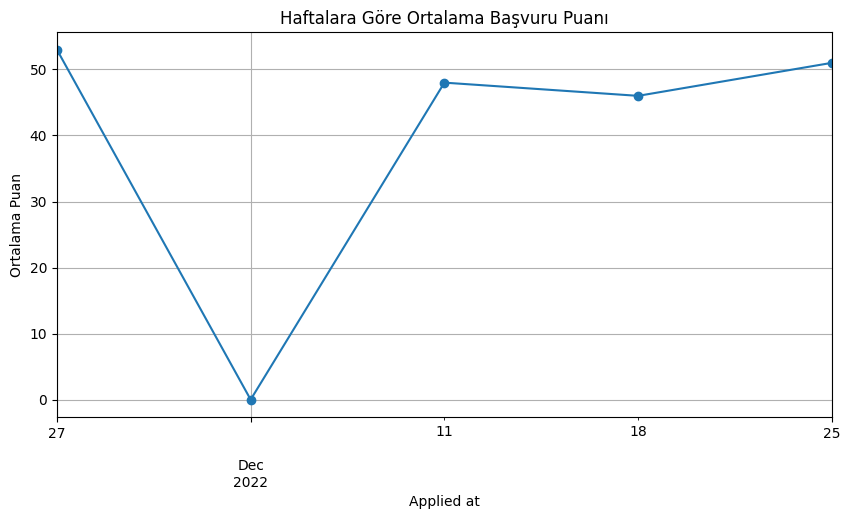

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

dfg["Application Score"].plot(marker="o")

plt.title("Haftalara Göre Ortalama Başvuru Puanı")
plt.xlabel("Applied at")
plt.ylabel("Ortalama Puan")
plt.grid(True)

plt.show()

In [22]:
weekly = weekly.sort_index()

## Sonuç

Bu çalışmada başvuru verileri temizlenmiş, sektör puanları ile birleştirilmiş ve belirlenen kurallara göre başvuru puanları hesaplanmıştır. Ardından kabul edilen başvurular seçilmiş, haftalara göre gruplanmış ve ortalama puanları grafik üzerinde gösterilmiştir.
